In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/victorsoeiro/netflix-tv-shows-and-movies/credits.csv
/kaggle/input/datasets/victorsoeiro/netflix-tv-shows-and-movies/titles.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/victorsoeiro/netflix-tv-shows-and-movies/titles.csv')

In [3]:
df.head(5)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

In [5]:
df.shape

(5850, 15)

In [6]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64

In [7]:
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].median())

In [8]:
df['imdb_votes']= df['imdb_votes'].fillna(df['imdb_votes'].median())

In [9]:
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].median())

In [10]:
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].median())

In [11]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score                 0
imdb_votes                 0
tmdb_popularity            0
tmdb_score                 0
dtype: int64

In [12]:
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].median())

In [13]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score                 0
imdb_votes                 0
tmdb_popularity            0
tmdb_score                 0
dtype: int64

In [14]:
df.shape

(5850, 15)

In [15]:
df['imdb_score'].describe()

count    5850.000000
mean        6.518205
std         1.115111
min         1.500000
25%         5.900000
50%         6.600000
75%         7.300000
max         9.600000
Name: imdb_score, dtype: float64

In [16]:
df = df.drop(columns=['imdb_score'])

In [17]:
df.shape

(5850, 14)

In [18]:
df

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,2233.5,0.600,6.900
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,72662.0,20.398,7.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5845,tm1014599,Fine Wine,MOVIE,A beautiful love story that can happen between...,2021,NaN,100,"['romance', 'drama']",['NG'],NaN,tt13857480,45.0,1.466,6.900
5846,tm898842,C/O Kaadhal,MOVIE,A heart warming film that explores the concept...,2021,NaN,134,['drama'],[],NaN,tt11803618,348.0,6.821,6.900
5847,tm1059008,Lokillo,MOVIE,A controversial TV host and comedian who has b...,2021,NaN,90,['comedy'],['CO'],NaN,tt14585902,68.0,26.005,6.300
5848,tm1035612,Dad Stop Embarrassing Me - The Afterparty,MOVIE,"Jamie Foxx, David Alan Grier and more from the...",2021,PG-13,37,[],['US'],NaN,NaN,2233.5,1.296,10.000


In [19]:
df.isnull().sum()

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_votes                 0
tmdb_popularity            0
tmdb_score                 0
dtype: int64

In [20]:
df = df.dropna(subset=['title'])

In [21]:
df.isnull().sum()

id                         0
title                      0
type                       0
description               17
release_year               0
age_certification       2618
runtime                    0
genres                     0
production_countries       0
seasons                 3743
imdb_id                  403
imdb_votes                 0
tmdb_popularity            0
tmdb_score                 0
dtype: int64

In [22]:
df['description'] = df['description'].fillna("No description available")

/tmp/ipykernel_17/1364848619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['description'] = df['description'].fillna("No description available")


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5849 entries, 0 to 5849
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5849 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5849 non-null   object 
 3   description           5849 non-null   object 
 4   release_year          5849 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5849 non-null   int64  
 7   genres                5849 non-null   object 
 8   production_countries  5849 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5446 non-null   object 
 11  imdb_votes            5849 non-null   float64
 12  tmdb_popularity       5849 non-null   float64
 13  tmdb_score            5849 non-null   float64
dtypes: float64(4), int64(2), object(8)
memory usage: 685.4+ KB


In [24]:
df = df.drop(columns=['id', 'description', 'seasons'])

In [25]:
df.shape

(5849, 11)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5849 entries, 0 to 5849
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 5849 non-null   object 
 1   type                  5849 non-null   object 
 2   release_year          5849 non-null   int64  
 3   age_certification     3231 non-null   object 
 4   runtime               5849 non-null   int64  
 5   genres                5849 non-null   object 
 6   production_countries  5849 non-null   object 
 7   imdb_id               5446 non-null   object 
 8   imdb_votes            5849 non-null   float64
 9   tmdb_popularity       5849 non-null   float64
 10  tmdb_score            5849 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 548.3+ KB


In [27]:
df['type'] = df['type'].astype('category')

In [28]:
df['age_certification'] = df['age_certification'].astype('category')

In [29]:
df['imdb_votes'] = df['imdb_votes'].astype('int64')

In [30]:
df['release_year'] = df['release_year'].astype('int16')
df['runtime'] = df['runtime'].astype('int16')

### "Because categorical variables have limited unique values, converting them to category reduces memory usage and improves performance."

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5849 entries, 0 to 5849
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   title                 5849 non-null   object  
 1   type                  5849 non-null   category
 2   release_year          5849 non-null   int16   
 3   age_certification     3231 non-null   category
 4   runtime               5849 non-null   int16   
 5   genres                5849 non-null   object  
 6   production_countries  5849 non-null   object  
 7   imdb_id               5446 non-null   object  
 8   imdb_votes            5849 non-null   int64   
 9   tmdb_popularity       5849 non-null   float64 
 10  tmdb_score            5849 non-null   float64 
dtypes: category(2), float64(2), int16(2), int64(1), object(4)
memory usage: 400.3+ KB


In [32]:
df.describe()

,release_year,runtime,imdb_votes,tmdb_popularity,tmdb_score
count,5849.000000,5849.000000,5.849000e+03,5849.000000,5849.000000
mean,2016.417336,76.900154,2.163744e+04,22.394546,6.832929
std,6.938294,38.996325,9.184894e+04,81.072685,1.139059
min,1945.000000,0.000000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,6.040000e+02,2.765000,6.200000
50%,2018.000000,83.000000,2.233000e+03,6.821000,6.900000
75%,2020.000000,104.000000,7.982000e+03,16.244000,7.500000
max,2022.000000,240.000000,2.294231e+06,2274.044000,10.000000


<Axes: title={'center': 'Movies vs TV Shows'}, xlabel='type'>

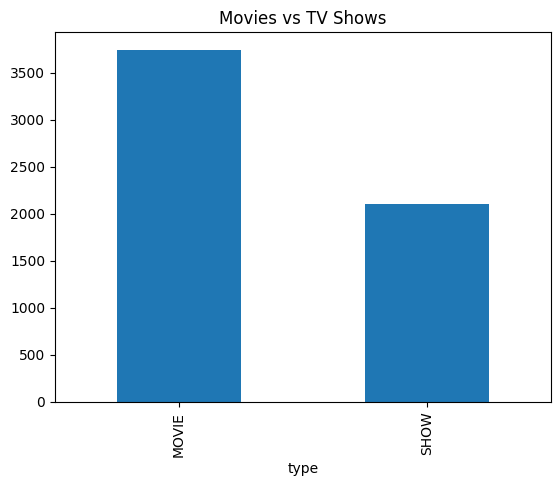

In [33]:
df['type'].value_counts().plot(kind='bar', title="Movies vs TV Shows")


<Axes: title={'center': 'Top Genres'}, xlabel='genres'>

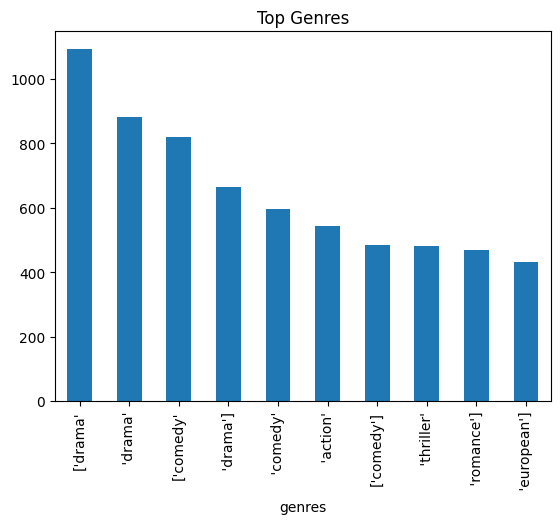

In [34]:
df['genres'] = df['genres'].str.split(',')
df_exploded = df.explode('genres')

df_exploded['genres'].value_counts().head(10).plot(kind='bar', title="Top Genres")

<Axes: title={'center': 'Top Countries'}, xlabel='production_countries'>

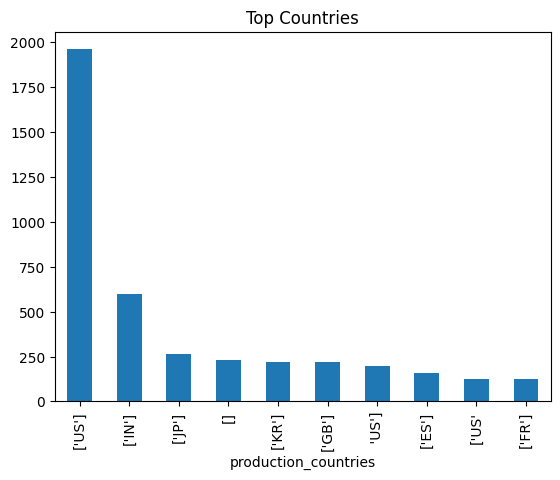

In [35]:
df['production_countries'] = df['production_countries'].str.split(',')
df_country = df.explode('production_countries')

df_country['production_countries'].value_counts().head(10).plot(kind='bar', title="Top Countries")

<Axes: title={'center': 'Content Release Trend'}, xlabel='release_year'>

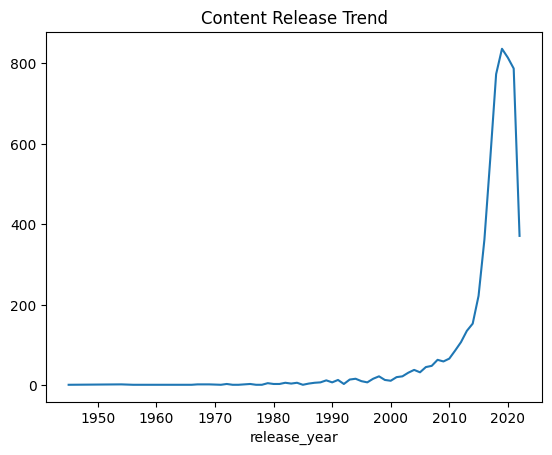

In [36]:
df['release_year'].value_counts().sort_index().plot(kind='line', title="Content Release Trend")

<Axes: title={'center': 'TMDB Score Distribution'}, ylabel='Frequency'>

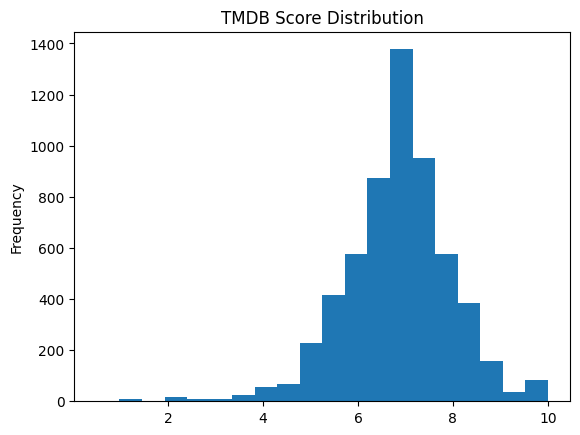

In [37]:
df['tmdb_score'].plot(kind='hist', bins=20, title="TMDB Score Distribution")

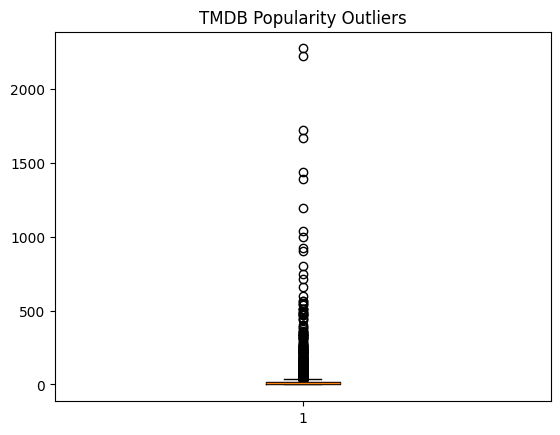

In [38]:
import matplotlib.pyplot as plt

plt.boxplot(df['tmdb_popularity'])
plt.title("TMDB Popularity Outliers")
plt.show()

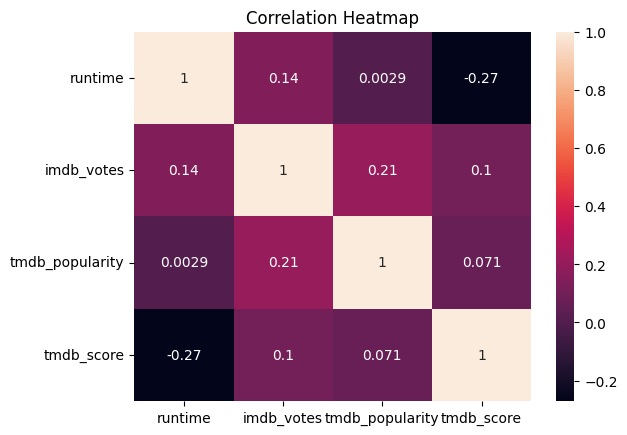

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['runtime','imdb_votes','tmdb_popularity','tmdb_score']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [40]:
df.to_csv("cleaned_movies_data.csv", index=False)
